<a href="https://colab.research.google.com/github/IoannisChamos/orchard-precision-farming/blob/main/01_build_orchard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
!pip install geopandas rasterio networkx laspy

In [42]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [43]:
from shapely.geometry import Point, LineString, box

In [44]:
crs = "EPSG:28992"

In [45]:
field_geometry = box(
    110000,
    480000,
    110120,
    480080
)

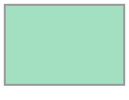

In [46]:
field_geometry

In [47]:
min_x = 110000
min_y = 480000
max_x = 110120
max_y = 480080

field_geometry = box(min_x, min_y, max_x, max_y)

In [48]:
field = gpd.GeoDataFrame(
    {
        "field_id": ["orchard_01"],
        "crop": ["apple"]
    },
    geometry=[field_geometry],
    crs=crs
)

In [49]:
field

,field_id,crop,geometry
0,orchard_01,apple,"POLYGON ((110120 480000, 110120 480080, 110000..."


In [50]:
print("Coordinate system:", field.crs)
print("Field area:", field.geometry.area.iloc[0], "m²")
print("Valid geometry:", field.geometry.is_valid.iloc[0])

Coordinate system: EPSG:28992
Field area: 9600.0 m²
Valid geometry: True


In [51]:
row_01_geometry = LineString([
    (110010, 480008),
    (110010, 480072)
])

In [52]:
row_01 = gpd.GeoDataFrame(
    {
        "row_id": ["R01"]
    },
    geometry=[row_01_geometry],
    crs=crs
)

In [53]:
print("Row length:", row_01.geometry.length.iloc[0], "m")

Row length: 64.0 m


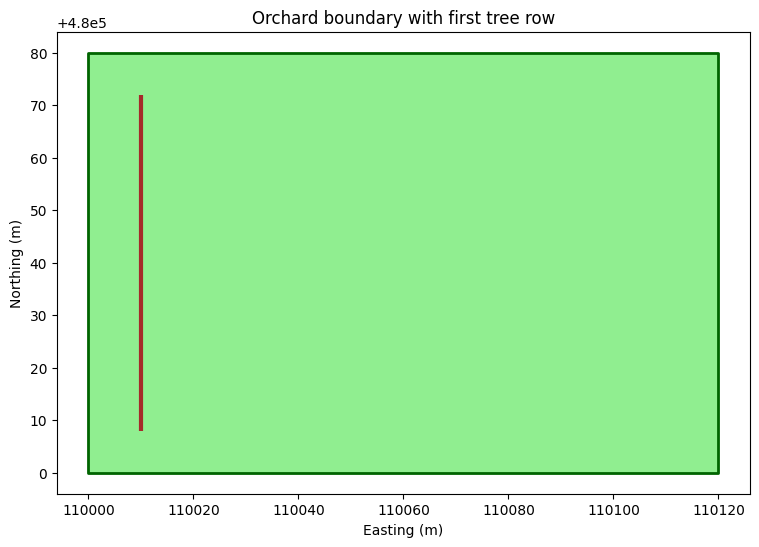

In [54]:
fig, ax = plt.subplots(figsize=(10, 6))

field.plot(
    ax=ax,
    facecolor="lightgreen",
    edgecolor="darkgreen",
    linewidth=2
)

row_01.plot(
    ax=ax,
    color="brown",
    linewidth=3
)

ax.set_title("Orchard boundary with first tree row")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")

plt.show()

In [55]:
fig.set_size_inches(12, 8)

In [56]:
row_records = []
for row_number, x_coordinate in enumerate(range(110010, 110119, 9),
                                          start=1
):
    row_id = f"R{row_number:02d}"
    row_geometry = LineString([
        (x_coordinate, 480008),
        (x_coordinate, 480072)
    ])
    row_records.append({"row_id": row_id, "geometry": row_geometry})

In [57]:
row_records

[{'row_id': 'R01', 'geometry': <LINESTRING (110010 480008, 110010 480072)>},
 {'row_id': 'R02', 'geometry': <LINESTRING (110019 480008, 110019 480072)>},
 {'row_id': 'R03', 'geometry': <LINESTRING (110028 480008, 110028 480072)>},
 {'row_id': 'R04', 'geometry': <LINESTRING (110037 480008, 110037 480072)>},
 {'row_id': 'R05', 'geometry': <LINESTRING (110046 480008, 110046 480072)>},
 {'row_id': 'R06', 'geometry': <LINESTRING (110055 480008, 110055 480072)>},
 {'row_id': 'R07', 'geometry': <LINESTRING (110064 480008, 110064 480072)>},
 {'row_id': 'R08', 'geometry': <LINESTRING (110073 480008, 110073 480072)>},
 {'row_id': 'R09', 'geometry': <LINESTRING (110082 480008, 110082 480072)>},
 {'row_id': 'R10', 'geometry': <LINESTRING (110091 480008, 110091 480072)>},
 {'row_id': 'R11', 'geometry': <LINESTRING (110100 480008, 110100 480072)>},
 {'row_id': 'R12', 'geometry': <LINESTRING (110109 480008, 110109 480072)>},
 {'row_id': 'R13', 'geometry': <LINESTRING (110118 480008, 110118 480072)>}]

In [58]:
rows = gpd.GeoDataFrame(
    row_records,
    geometry="geometry",
    crs=crs
)

In [59]:
print("Number of rows:", len(rows))
print("Average row length:", rows.geometry.length.mean(), "m")

rows

Number of rows: 13
Average row length: 64.0 m


,row_id,geometry
0,R01,"LINESTRING (110010 480008, 110010 480072)"
1,R02,"LINESTRING (110019 480008, 110019 480072)"
2,R03,"LINESTRING (110028 480008, 110028 480072)"
3,R04,"LINESTRING (110037 480008, 110037 480072)"
4,R05,"LINESTRING (110046 480008, 110046 480072)"
5,R06,"LINESTRING (110055 480008, 110055 480072)"
6,R07,"LINESTRING (110064 480008, 110064 480072)"
7,R08,"LINESTRING (110073 480008, 110073 480072)"
8,R09,"LINESTRING (110082 480008, 110082 480072)"
9,R10,"LINESTRING (110091 480008, 110091 480072)"


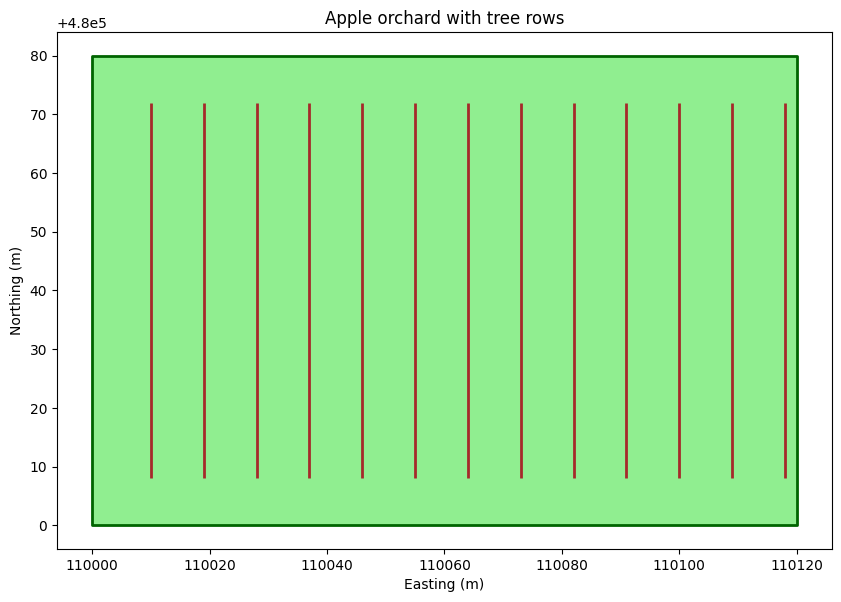

In [60]:
fig, ax = plt.subplots(figsize=(10, 7))

field.plot(
    ax=ax,
    facecolor="lightgreen",
    edgecolor="darkgreen",
    linewidth=2
)

rows.plot(
    ax=ax,
    color="brown",
    linewidth=2
)

ax.set_title("Apple orchard with tree rows")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_aspect("equal")

plt.show()

In [61]:
tree_records = []

for _, row in rows.iterrows():

    for tree_number, y_coordinate in enumerate(
        range(480010, 480071, 4),
        start=1
    ):
        tree_id = f"{row['row_id']}_T{tree_number:02d}"

        tree_geometry = Point(
            row.geometry.coords[0][0],
            y_coordinate
        )

        tree_records.append({
            "tree_id": tree_id,
            "row_id": row["row_id"],
            "species": "apple",
            "geometry": tree_geometry
        })

In [62]:
tree_records

[{'tree_id': 'R01_T01',
  'row_id': 'R01',
  'species': 'apple',
  'geometry': <POINT (110010 480010)>},
 {'tree_id': 'R01_T02',
  'row_id': 'R01',
  'species': 'apple',
  'geometry': <POINT (110010 480014)>},
 {'tree_id': 'R01_T03',
  'row_id': 'R01',
  'species': 'apple',
  'geometry': <POINT (110010 480018)>},
 {'tree_id': 'R01_T04',
  'row_id': 'R01',
  'species': 'apple',
  'geometry': <POINT (110010 480022)>},
 {'tree_id': 'R01_T05',
  'row_id': 'R01',
  'species': 'apple',
  'geometry': <POINT (110010 480026)>},
 {'tree_id': 'R01_T06',
  'row_id': 'R01',
  'species': 'apple',
  'geometry': <POINT (110010 480030)>},
 {'tree_id': 'R01_T07',
  'row_id': 'R01',
  'species': 'apple',
  'geometry': <POINT (110010 480034)>},
 {'tree_id': 'R01_T08',
  'row_id': 'R01',
  'species': 'apple',
  'geometry': <POINT (110010 480038)>},
 {'tree_id': 'R01_T09',
  'row_id': 'R01',
  'species': 'apple',
  'geometry': <POINT (110010 480042)>},
 {'tree_id': 'R01_T10',
  'row_id': 'R01',
  'species':

In [63]:
trees = gpd.GeoDataFrame(
    tree_records,
    geometry="geometry",
    crs=crs
)

In [64]:
print("Number of trees:", len(trees))
print("Coordinate system:", trees.crs)
print("All geometries valid:", trees.geometry.is_valid.all())

trees.head()

Number of trees: 208
Coordinate system: EPSG:28992
All geometries valid: True


,tree_id,row_id,species,geometry
0,R01_T01,R01,apple,POINT (110010 480010)
1,R01_T02,R01,apple,POINT (110010 480014)
2,R01_T03,R01,apple,POINT (110010 480018)
3,R01_T04,R01,apple,POINT (110010 480022)
4,R01_T05,R01,apple,POINT (110010 480026)


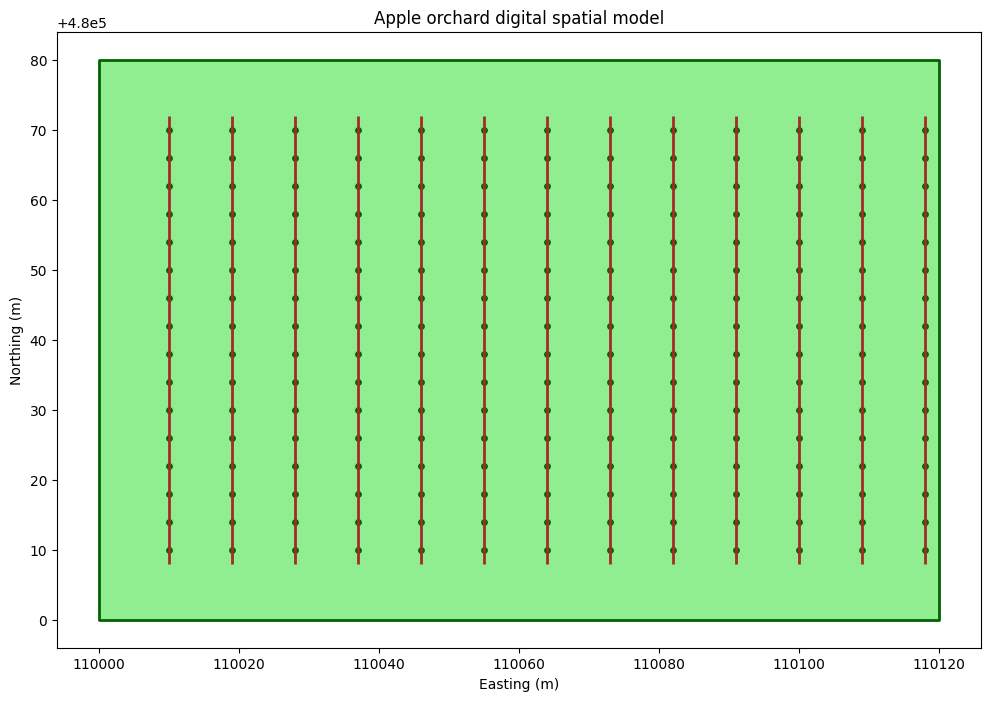

In [65]:
fig, ax = plt.subplots(figsize=(12, 8))

field.plot(
    ax=ax,
    facecolor="lightgreen",
    edgecolor="darkgreen",
    linewidth=2
)

rows.plot(
    ax=ax,
    color="brown",
    linewidth=2
)

trees.plot(
    ax=ax,
    color="darkgreen",
    markersize=15
)

ax.set_title("Apple orchard digital spatial model")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_aspect("equal")

plt.show()

In [66]:
import numpy as np

In [67]:
np.random.seed(42)

gps_records = []

timestamp = pd.Timestamp("2026-08-24 09:00:00")

for row_index, row in rows.iloc[:3].iterrows():

    y_coordinates = np.arange(
        480010,
        480071,
        4
    )

    if row_index % 2 == 1:
        y_coordinates = y_coordinates[::-1]

    for y_coordinate in y_coordinates:

        gps_records.append({
            "timestamp": timestamp,
            "x": row.geometry.coords[0][0] + np.random.normal(0, 0.4),
            "y": y_coordinate + np.random.normal(0, 0.4),
            "speed_m_s": np.random.normal(1.8, 0.15),
            "application_rate": np.random.normal(100, 5)
        })

        timestamp = timestamp + pd.Timedelta(seconds=2)

In [68]:
gps_records

[{'timestamp': Timestamp('2026-08-24 09:00:00'),
  'x': 110010.1986856612,
  'y': np.float64(480009.9446942795),
  'speed_m_s': 1.897153280715104,
  'application_rate': 107.61514928204012},
 {'timestamp': Timestamp('2026-08-24 09:00:02'),
  'x': 110009.90633865011,
  'y': np.float64(480013.9063452172),
  'speed_m_s': 2.036881922326109,
  'application_rate': 103.83717364576455},
 {'timestamp': Timestamp('2026-08-24 09:00:04'),
  'x': 110009.81221024563,
  'y': np.float64(480018.2170240174),
  'speed_m_s': 1.7304873460781307,
  'application_rate': 97.67135123214871},
 {'timestamp': Timestamp('2026-08-24 09:00:06'),
  'x': 110010.09678490863,
  'y': np.float64(480021.23468790215),
  'speed_m_s': 1.541262325123045,
  'application_rate': 97.18856235379513},
 {'timestamp': Timestamp('2026-08-24 09:00:08'),
  'x': 110009.59486755186,
  'y': np.float64(480026.125698933),
  'speed_m_s': 1.6637963886718183,
  'application_rate': 92.93848149332354},
 {'timestamp': Timestamp('2026-08-24 09:00:10')

In [69]:
gps_df = pd.DataFrame(gps_records)

In [70]:
gps_df.head()

,timestamp,x,y,speed_m_s,application_rate
0,2026-08-24 09:00:00,110010.198686,480009.944694,1.897153,107.615149
1,2026-08-24 09:00:02,110009.906339,480013.906345,2.036882,103.837174
2,2026-08-24 09:00:04,110009.812210,480018.217024,1.730487,97.671351
3,2026-08-24 09:00:06,110010.096785,480021.234688,1.541262,97.188562
4,2026-08-24 09:00:08,110009.594868,480026.125699,1.663796,92.938481


In [72]:
gps_df = pd.DataFrame(gps_records)

print("GPS DataFrame created:", len(gps_df))

GPS DataFrame created: 48


In [73]:
gps_clean = gps_df.dropna(
    subset=["x", "y"]
).copy()

gps_gdf = gpd.GeoDataFrame(
    gps_clean,
    geometry=gpd.points_from_xy(
        gps_clean["x"],
        gps_clean["y"]
    ),
    crs=crs
)

print("GPS GeoDataFrame created:", len(gps_gdf))

GPS GeoDataFrame created: 48


In [74]:
gps_gdf.head()

,timestamp,x,y,speed_m_s,application_rate,geometry
0,2026-08-24 09:00:00,110010.198686,480009.944694,1.897153,107.615149,POINT (110010.199 480009.945)
1,2026-08-24 09:00:02,110009.906339,480013.906345,2.036882,103.837174,POINT (110009.906 480013.906)
2,2026-08-24 09:00:04,110009.812210,480018.217024,1.730487,97.671351,POINT (110009.812 480018.217)
3,2026-08-24 09:00:06,110010.096785,480021.234688,1.541262,97.188562,POINT (110010.097 480021.235)
4,2026-08-24 09:00:08,110009.594868,480026.125699,1.663796,92.938481,POINT (110009.595 480026.126)


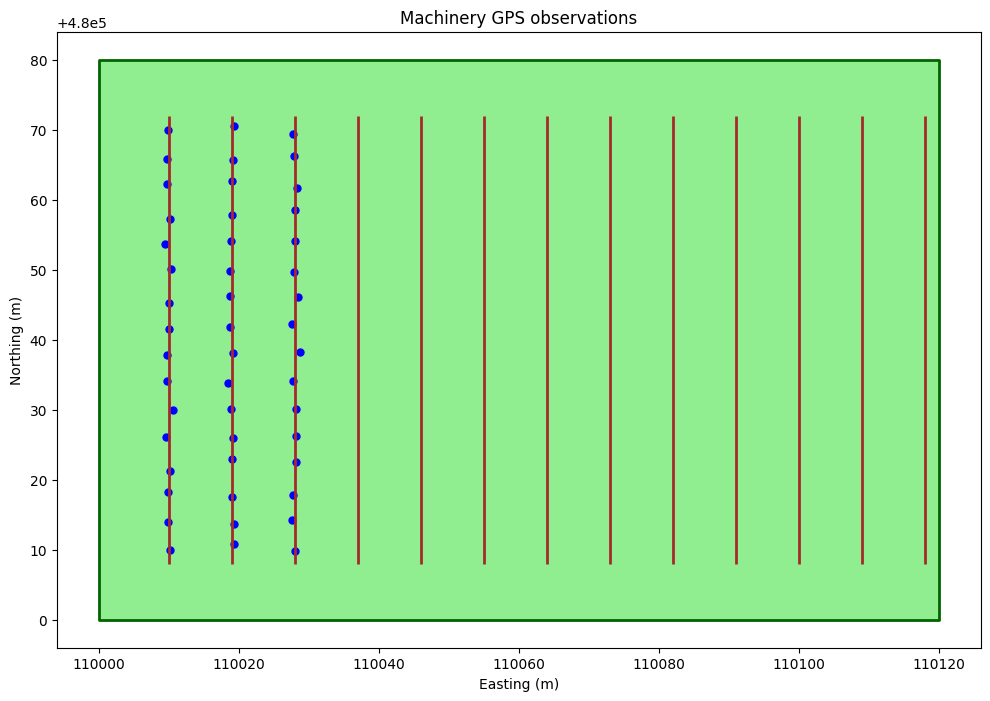

In [75]:
fig, ax = plt.subplots(figsize=(12, 8))

field.plot(
    ax=ax,
    facecolor="lightgreen",
    edgecolor="darkgreen",
    linewidth=2
)

rows.plot(
    ax=ax,
    color="brown",
    linewidth=2
)

gps_gdf.plot(
    ax=ax,
    color="blue",
    markersize=25
)

ax.set_title("Machinery GPS observations")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_aspect("equal")

plt.show()

In [76]:
gps_with_rows = gpd.sjoin_nearest(
    gps_gdf,
    rows[["row_id", "geometry"]],
    how="left",
    distance_col="distance_to_row_m"
)

In [77]:
gps_with_rows[
    [
        "timestamp",
        "x",
        "y",
        "row_id",
        "distance_to_row_m"
    ]
].head(10)

,timestamp,x,y,row_id,distance_to_row_m
0,2026-08-24 09:00:00,110010.198686,480009.944694,R01,0.198686
1,2026-08-24 09:00:02,110009.906339,480013.906345,R01,0.093661
2,2026-08-24 09:00:04,110009.812210,480018.217024,R01,0.187790
3,2026-08-24 09:00:06,110010.096785,480021.234688,R01,0.096785
4,2026-08-24 09:00:08,110009.594868,480026.125699,R01,0.405132
5,2026-08-24 09:00:10,110010.586260,480029.909689,R01,0.586260
6,2026-08-24 09:00:12,110009.782247,480034.044369,R01,0.217753
7,2026-08-24 09:00:14,110009.759745,480037.883323,R01,0.240255
8,2026-08-24 09:00:16,110009.994601,480041.576916,R01,0.005399
9,2026-08-24 09:00:18,110010.083545,480045.216132,R01,0.083545


In [78]:
gps_with_rows["distance_to_row_m"].describe()


,distance_to_row_m
count,48.000000
mean,0.220617
std,0.172284
min,0.005201
25%,0.090584
50%,0.203731
75%,0.318159
max,0.746310


In [79]:
gps_with_rows.groupby("row_id").size()


,0
row_id,
R01,16
R02,16
R03,16


In [80]:
row_summary = gps_with_rows.groupby("row_id").agg(
    observations=("timestamp", "count"),
    mean_speed_m_s=("speed_m_s", "mean"),
    mean_application_rate=("application_rate", "mean"),
    maximum_distance_m=("distance_to_row_m", "max")
)

row_summary

,observations,mean_speed_m_s,mean_application_rate,maximum_distance_m
row_id,,,,
R01,16,1.771345,100.222170,0.591409
R02,16,1.807989,99.652514,0.566148
R03,16,1.752284,101.441924,0.746310


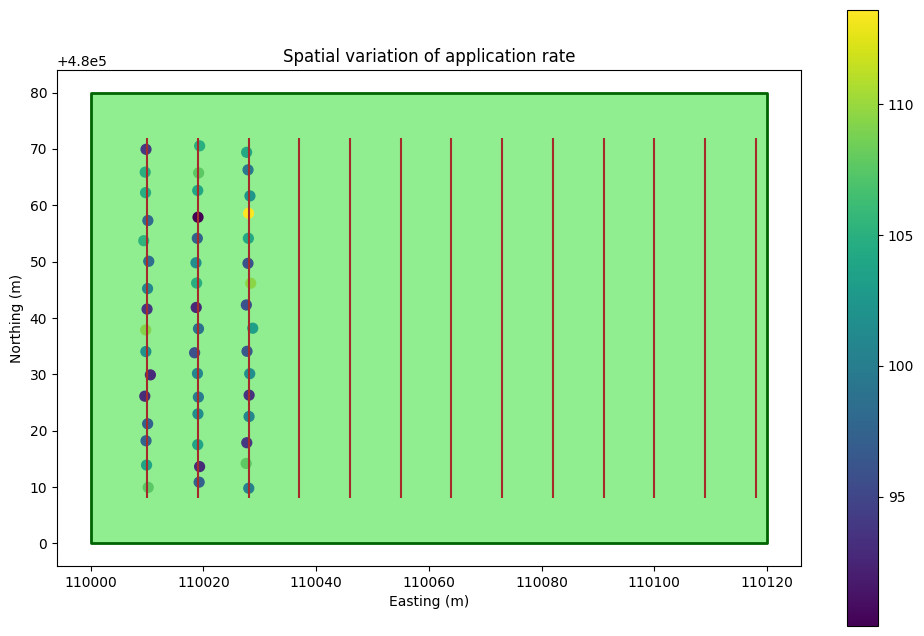

In [81]:
fig, ax = plt.subplots(figsize=(12, 8))

field.plot(
    ax=ax,
    facecolor="lightgreen",
    edgecolor="darkgreen",
    linewidth=2
)

rows.plot(
    ax=ax,
    color="brown",
    linewidth=1.5
)

gps_with_rows.plot(
    ax=ax,
    column="application_rate",
    cmap="viridis",
    legend=True,
    markersize=50
)

ax.set_title("Spatial variation of application rate")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_aspect("equal")

plt.show()

In [82]:
maximum_rate_index = gps_with_rows[
    "application_rate"
].idxmax()

gps_with_rows.loc[
    maximum_rate_index,
    [
        "timestamp",
        "row_id",
        "x",
        "y",
        "speed_m_s",
        "application_rate"
    ]
]

,44
timestamp,2026-08-24 09:01:28
row_id,R03
x,110028.005201
y,480058.581414
speed_m_s,1.760301
application_rate,113.600846


In [83]:
np.random.seed(7)

trees["canopy_volume_m3"] = np.random.uniform(
    2,
    8,
    len(trees)
)

trees["disease_risk"] = np.random.uniform(
    0,
    1,
    len(trees)
)

In [84]:
trees["required_rate_l_ha"] = (
    50
    + 6 * trees["canopy_volume_m3"]
    + 25 * trees["disease_risk"]
)

In [85]:
trees[
    [
        "tree_id",
        "row_id",
        "canopy_volume_m3",
        "disease_risk",
        "required_rate_l_ha"
    ]
].head()

,tree_id,row_id,canopy_volume_m3,disease_risk,required_rate_l_ha
0,R01_T01,R01,2.457850,0.656450,81.158356
1,R01_T02,R01,6.679513,0.146930,93.750334
2,R01_T03,R01,4.630455,0.973476,102.119622
3,R01_T04,R01,6.340791,0.955383,111.929333
4,R01_T05,R01,7.867937,0.424626,107.823261


In [86]:
gps_for_tree_join = gps_with_rows.drop(
    columns=["index_right"],
    errors="ignore"
)

In [87]:
gps_with_trees = gpd.sjoin_nearest(
    gps_for_tree_join,
    trees[
        [
            "tree_id",
            "canopy_volume_m3",
            "disease_risk",
            "required_rate_l_ha",
            "geometry"
        ]
    ],
    how="left",
    distance_col="distance_to_tree_m"
)

In [88]:
gps_with_trees

,timestamp,x,y,speed_m_s,application_rate,geometry,row_id,distance_to_row_m,index_right,tree_id,canopy_volume_m3,disease_risk,required_rate_l_ha,distance_to_tree_m
0,2026-08-24 09:00:00,110010.198686,480009.944694,1.897153,107.615149,POINT (110010.199 480009.945),R01,0.198686,0,R01_T01,2.457850,0.656450,81.158356,0.206239
1,2026-08-24 09:00:02,110009.906339,480013.906345,2.036882,103.837174,POINT (110009.906 480013.906),R01,0.093661,1,R01_T02,6.679513,0.146930,93.750334,0.132453
2,2026-08-24 09:00:04,110009.812210,480018.217024,1.730487,97.671351,POINT (110009.812 480018.217),R01,0.187790,2,R01_T03,4.630455,0.973476,102.119622,0.286992
3,2026-08-24 09:00:06,110010.096785,480021.234688,1.541262,97.188562,POINT (110010.097 480021.235),R01,0.096785,3,R01_T04,6.340791,0.955383,111.929333,0.771408
4,2026-08-24 09:00:08,110009.594868,480026.125699,1.663796,92.938481,POINT (110009.595 480026.126),R01,0.405132,4,R01_T05,7.867937,0.424626,107.823261,0.424185
5,2026-08-24 09:00:10,110010.586260,480029.909689,1.810129,92.876259,POINT (110010.586 480029.91),R01,0.586260,5,R01_T06,5.230975,0.593637,96.226785,0.593175
6,2026-08-24 09:00:12,110009.782247,480034.044369,1.627351,101.878490,POINT (110009.782 480034.044),R01,0.217753,6,R01_T07,5.006723,0.039629,81.031051,0.222227
7,2026-08-24 09:00:14,110009.759745,480037.883323,1.709744,109.261391,POINT (110009.76 480037.883),R01,0.240255,7,R01_T08,2.432307,0.988634,89.309699,0.267089
8,2026-08-24 09:00:16,110009.994601,480041.576916,1.923382,93.895782,POINT (110009.995 480041.577),R01,0.005399,8,R01_T09,3.610634,0.818745,92.132428,0.423119
9,2026-08-24 09:00:18,110010.083545,480045.216132,1.600772,100.984306,POINT (110010.084 480045.216),R01,0.083545,9,R01_T10,4.999295,0.636502,95.908329,0.788308


In [89]:
gps_with_trees["actual_rate_l_ha"] = gps_with_trees[
    "application_rate"
]

gps_with_trees["rate_error_l_ha"] = (
    gps_with_trees["actual_rate_l_ha"]
    - gps_with_trees["required_rate_l_ha"]
)

In [90]:
gps_with_trees[
    [
        "timestamp",
        "row_id",
        "tree_id",
        "actual_rate_l_ha",
        "required_rate_l_ha",
        "rate_error_l_ha",
        "distance_to_tree_m"
    ]
].head(10)

,timestamp,row_id,tree_id,actual_rate_l_ha,required_rate_l_ha,rate_error_l_ha,distance_to_tree_m
0,2026-08-24 09:00:00,R01,R01_T01,107.615149,81.158356,26.456794,0.206239
1,2026-08-24 09:00:02,R01,R01_T02,103.837174,93.750334,10.086839,0.132453
2,2026-08-24 09:00:04,R01,R01_T03,97.671351,102.119622,-4.448270,0.286992
3,2026-08-24 09:00:06,R01,R01_T04,97.188562,111.929333,-14.740770,0.771408
4,2026-08-24 09:00:08,R01,R01_T05,92.938481,107.823261,-14.884779,0.424185
5,2026-08-24 09:00:10,R01,R01_T06,92.876259,96.226785,-3.350526,0.593175
6,2026-08-24 09:00:12,R01,R01_T07,101.878490,81.031051,20.847439,0.222227
7,2026-08-24 09:00:14,R01,R01_T08,109.261391,89.309699,19.951692,0.267089
8,2026-08-24 09:00:16,R01,R01_T09,93.895782,92.132428,1.763354,0.423119
9,2026-08-24 09:00:18,R01,R01_T10,100.984306,95.908329,5.075978,0.788308


In [94]:
tolerance = 5

In [95]:
gps_with_trees["application_status"] = np.select(
    [
        gps_with_trees["rate_error_l_ha"] < -tolerance,
        gps_with_trees["rate_error_l_ha"] > tolerance
    ],
    [
        "Under-application",
        "Over-application"
    ],
    default="Within tolerance"
)

In [96]:
gps_with_trees[
    [
        "tree_id",
        "actual_rate_l_ha",
        "required_rate_l_ha",
        "rate_error_l_ha",
        "application_status"
    ]
].head(10)

,tree_id,actual_rate_l_ha,required_rate_l_ha,rate_error_l_ha,application_status
0,R01_T01,107.615149,81.158356,26.456794,Over-application
1,R01_T02,103.837174,93.750334,10.086839,Over-application
2,R01_T03,97.671351,102.119622,-4.448270,Within tolerance
3,R01_T04,97.188562,111.929333,-14.740770,Under-application
4,R01_T05,92.938481,107.823261,-14.884779,Under-application
5,R01_T06,92.876259,96.226785,-3.350526,Within tolerance
6,R01_T07,101.878490,81.031051,20.847439,Over-application
7,R01_T08,109.261391,89.309699,19.951692,Over-application
8,R01_T09,93.895782,92.132428,1.763354,Within tolerance
9,R01_T10,100.984306,95.908329,5.075978,Over-application


In [97]:
status_counts = gps_with_trees[
    "application_status"
].value_counts()

status_counts

,count
application_status,
Over-application,26
Within tolerance,13
Under-application,9


In [98]:
within_tolerance_percentage = (
    gps_with_trees["application_status"]
    .eq("Within tolerance")
    .mean()
    * 100
)

print(
    "Observations within tolerance:",
    round(within_tolerance_percentage, 1),
    "%"
)

Observations within tolerance: 27.1 %


In [99]:
maximum_absolute_error = gps_with_trees[
    "rate_error_l_ha"
].abs().max()

print(
    "Maximum absolute error:",
    round(maximum_absolute_error, 2),
    "L/ha"
)

Maximum absolute error: 35.99 L/ha


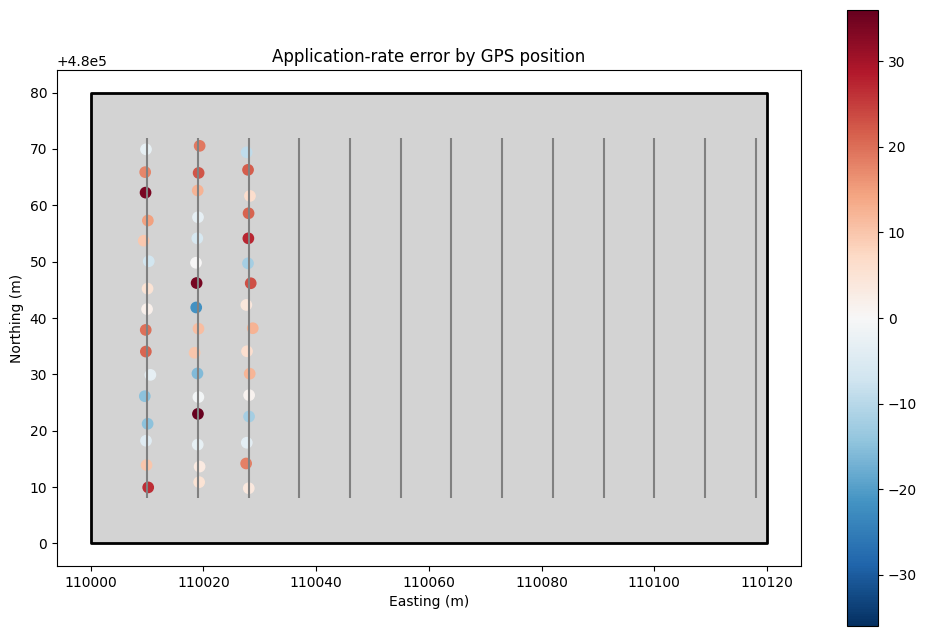

In [100]:
fig, ax = plt.subplots(figsize=(12, 8))

field.plot(
    ax=ax,
    facecolor="lightgray",
    edgecolor="black",
    linewidth=2
)

rows.plot(
    ax=ax,
    color="gray",
    linewidth=1.5
)

gps_with_trees.plot(
    ax=ax,
    column="rate_error_l_ha",
    cmap="RdBu_r",
    legend=True,
    markersize=55,
    vmin=-maximum_absolute_error,
    vmax=maximum_absolute_error
)

ax.set_title("Application-rate error by GPS position")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_aspect("equal")

plt.show()